## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Evie McMahan

**Date:** 9/30/2026

### Q1 ###

**1. What is the difference between regression and classification?**
- Regression and classification are two different types of machine learning models. Regression predicts a numeric outcome, and is therefore used when we want to predict numerical results. Classification predicts a categorical target, and is therefore used when we want to predict cateogrical results. You use `KNeighborsRegressor` for regression and `KNeighborsClassifier` for classification when using scikit-learn models. Additionally, when using regression, you average the neighbors when combining observed outcomes to determine the prediction result, whereas you take the majority for classification.

**2. What is a confusion table? What does it help us understand about a model's performance?**
- A confusion table counts predictions by actual class and predicted class. Column headers show whether the model predicts negative or positive results, and row headers show the actual classes. The result of the matrix (for a binary variable) is 4 scenarios: true negative, false positive, false negative, and true positive. It helps us understand which values are missclassified as false positives or false negatives when making a categorical prediction. This is helpful because metrics like the SSE don't show which values are missclassified, so we can't examine the classification errors. 

**3. What does the SSE quantify about a particular model?**
- The SSE is a single number that can be viewed as a ruler for model performance. For a particular k value, it quanitfies the error between the predictions and observations. It is calculated by suming the square of the difference between predictions for each sample of data in a fitted model.

**4. What are overfitting and underfitting?**
- Because predictions change when the set of nearest neighbors change, choosing the correct k is very important. Overfitting is when you choose a k that is too small, so the model captures too much noise in the data. This means that the predictions will vary a lot when you slighly change any input features. Underfitting is when you choose a k that is too large, so it captures too little of the datapoint and doesn't provide helpful insights. This means that no matter how much you vary the input, the predictions would be nearly the same.

**5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?**
- Splitting the data into training and testing sets allows you to test how well the model predicts new observations (the testing set), rather than just predicting the outcome variable that it has been trained on. Once you fit models on a training set, you then compare how they perform on the testing set. Choosing $k$ is particularly important because a main purpose of the model is to be able to generalize it, or make robust predictions on unseen data. Different $k$ values control this generalization ability of a model, like I discussed in the overfitting and underfitting question above. By iterating over different $k$ options, you can test the model on your testing set to determine the particular $k$ that has the lowest SSE or the highest accuracy. 

**6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.**
- The strengths of reporting a class label as a prediction are that it is simpler and easier to interpret, since the model predicts one output value for each combination of feature variables. This can be beneficial if there are many different classes that the output variable could land in, and it also allows you to build a confusion matrix. The main weakness of this approach is that it ignores how confident the model is in it's prediction. You could have a much more accurate model if you ignored the values that the model was least confident in.
- The strengths of reporting a probability distribution over class labels are that the model provides more information for you to interpret and you have information into how confident the model is with each prediction. However, the main weakness of this approach is that it can make interpretation much more challenging with an overload of data.

### Q2 ###

**1. Load the data. Perform some EDA, summarizing the target label and the features.**

In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

df = pd.read_csv("./data/land_mines.csv")
print(df.shape) 
df.head()

(338, 4)


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


The data has 4 variables and 338 observations. The target label is `mine_type`, and the feature variables are `voltage`, `height`, and `soil`. I will now explore the target label.

In [204]:
print('number of null values:', df['mine_type'].isnull().sum()) # Count null values
print(df['mine_type'].value_counts()) 
print(df['mine_type'].describe())

number of null values: 0
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
count    338.000000
mean       2.952663
std        1.419703
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: mine_type, dtype: float64


The target label of `mine_type` is an categorical variable that is an integer type. There are no null values, and it has 5 possible values: 1, 2, 3, 4, and 5. The most common mine type is 1 with 71 occurances, and the least common is 5 with 65 occurances. As `mine_type` increases, the number of occurances slightly decreases, although not to a meaningful degree.

number of null values: 0
count    338.000000
mean       0.430634
std        0.195819
min        0.197734
25%        0.309737
50%        0.359516
75%        0.482628
max        0.999999
Name: voltage, dtype: float64
voltage
0.999999    18
0.335347     7
0.314199     7
0.302114     7
0.296072     6
            ..
0.446284     1
0.391178     1
0.378157     1
0.319939     1
0.519637     1
Name: count, Length: 196, dtype: int64


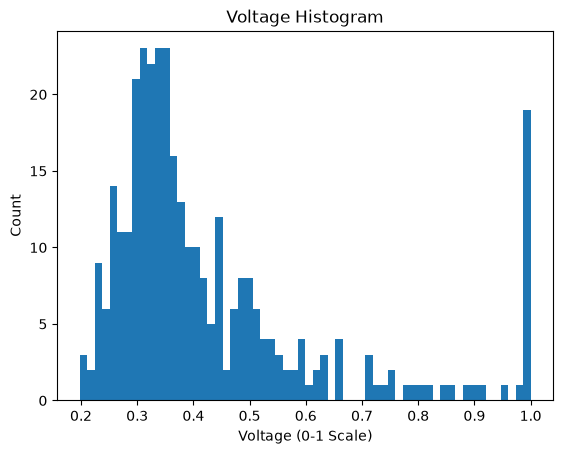

In [205]:
print('number of null values:', df['voltage'].isnull().sum()) # Count null values
print(df['voltage'].describe())
print(df['voltage'].value_counts())
voltage_hist = df['voltage'].hist(bins=60, grid=False) # Create histogram
voltage_hist.set_title('Voltage Histogram')
voltage_hist.set_xlabel('Voltage (0-1 Scale)')
voltage_hist.set_ylabel('Count')
plt.show()


`voltage` is a numeric feature variable that is already on a 0-1 scale, so no additional feature scaling is needed. It is a float object type with no null values. Values range from approximately 0.20 to 0.99, with a mean value of 0.43. The distribution is skewed right, as it has a long tail of higher values, and it has a spike at 0.99 with 18 observations at that value. 

number of null values: 0
count    338.000000
mean       0.508876
std        0.306043
min        0.000000
25%        0.272727
50%        0.545455
75%        0.727273
max        1.000000
Name: height, dtype: float64
height
0.181818    30
0.545455    30
0.636364    30
0.454545    29
0.727273    29
0.818182    29
0.363636    29
0.272727    28
0.909091    28
1.000000    27
0.090909    27
0.000000    22
Name: count, dtype: int64


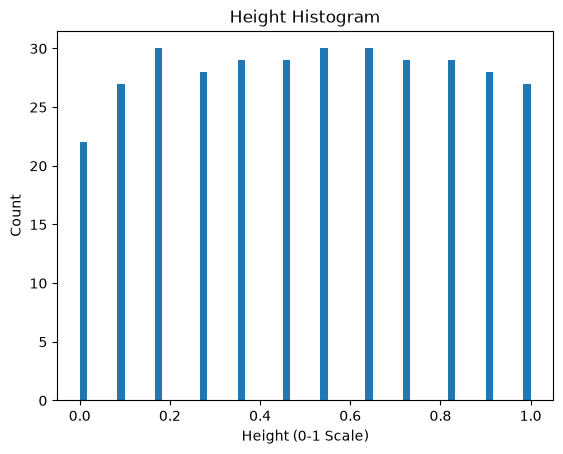

In [206]:
print('number of null values:', df['height'].isnull().sum()) # Count null values
print(df['height'].describe())
print(df['height'].value_counts())
height_hist = df['height'].hist(bins=60, grid=False) # Create histogram
height_hist.set_title('Height Histogram')
height_hist.set_xlabel('Height (0-1 Scale)')
height_hist.set_ylabel('Count')
plt.show()

`height` is also a numeric feature variable that has been scaled to fall between 0 and 1. It is a float object type with no null values. Height only has 12 distinct values, ranging from 0.0 to 1.0. I will keep 0.0, because that doesn't represent a height of 0 since the variable has been scaled. It instead represents the smallest height in the dataset. The mean height is 0.5, and the distribution is relatively uniform throughout each height. 

number of null values: 0
count    338.000000
mean       0.503550
std        0.344244
min        0.000000
25%        0.200000
50%        0.600000
75%        0.800000
max        1.000000
Name: soil, dtype: float64
soil
0.0    59
0.8    58
0.6    57
1.0    57
0.4    56
0.2    51
Name: count, dtype: int64


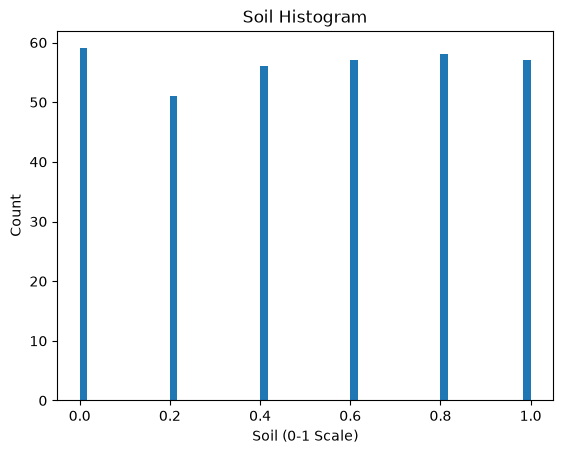

In [207]:
print('number of null values:', df['soil'].isnull().sum()) # Count null values
print(df['soil'].describe())
print(df['soil'].value_counts())
soil_hist = df['soil'].hist(bins=60, grid=False) # Create histogram
soil_hist.set_title('Soil Histogram')
soil_hist.set_xlabel('Soil (0-1 Scale)')
soil_hist.set_ylabel('Count')
plt.show()

Finally, `soil` is another feature variable that is already scaled to land between 0 and 1. There are only 6 distinct values (0.0, 0.2, 0.4, 0.6, 0.8, and 1.0). The distribution is relatively even among values, with 59 counts of 0.0 on the high end and 51 counts of 0.2 on the low end. There are no null values. Because each value is evenly spaced, and "soil" is not a measurable variable, it appears to be categorical where each value represents a different type of soil. However, I can't be positive.

Since the values of all the feature variables are already on a 0-1 scale, there is no need to do additional scaling before building the model.

**2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)**


In [208]:
X = df[['voltage','height','soil']] # Raw feature variables
y = df['mine_type'] # Target variable

X_train, X_valid, y_train, y_valid = train_test_split(X, y,
    test_size=0.5, random_state=65) # Split the data 50/50 into training and test/validation sets.

print(X_train.describe())

          voltage      height        soil
count  169.000000  169.000000  169.000000
mean     0.416000    0.532006    0.479290
std      0.183133    0.308232    0.354037
min      0.197734    0.000000    0.000000
25%      0.306495    0.272727    0.200000
50%      0.356495    0.545455    0.400000
75%      0.467341    0.818182    0.800000
max      0.999999    1.000000    1.000000


After spliting the data 50/50, I can see that my feature training data set has 169 rows, exactly half of the 338 rows in the initial dataset. 

**3. Build a $k$-NN classifier. Explain how you select $k$.**


In [209]:
k = round(len(X_train) ** 0.5) # Starting my model with a k that is based off the square root of n
print(k)

13


I started off by selecting k based on the square root of the number of rows in my training dataset. Because it was 13, I then chose to test the accuracy on different k's from 1-50, which covers a wide range around the square root of n. I use accuracy versus SSE to determine which k is best because the target is a categorical variable, and with categorical variables, the prediction is either correct or incorrect.  

In [210]:
ks = np.arange(1, 51) # Test ks from 1-50
valid_accuracy = [] # Empty lists to accumulate accuracies for different validation set ks  
train_accuracy = [] # Empty lists to accumulate accuracies for different training set ks  

for k in ks: # Loop through all the test ks
   candidate = KNeighborsClassifier(n_neighbors=int(k)) 
   candidate.fit(X_train, y_train)
   valid_hat = candidate.predict(X_valid)
   train_hat = candidate.predict(X_train)
   valid_accuracy.append(np.sum( # Sum the correct predictions / total predictions to determine the accuracy of the validation set
      (y_valid.to_numpy() == valid_hat) / len(y_valid)
   ))
   train_accuracy.append(np.sum( # Sum the correct predictions / total predicitons to determine the accuracy of the training set
      (y_train.to_numpy() == train_hat) / len(y_train)
   ))
k_star = int(ks[np.argmax(valid_accuracy)]) # Determine the k with the highest accuracy
print(f"k: {k_star}. Validation accuracy: {max(valid_accuracy):.1%}.")

k: 11. Validation accuracy: 43.8%.


For this split, the validation accuracy is highest at 43.8% when k = 11. I determined this by iterating through ks 1-50. For each k, I built a new classification model and fit the validation (and training) models, and then determined their accuracy by dividing the number of correct predictions by total predictions.

**4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?**

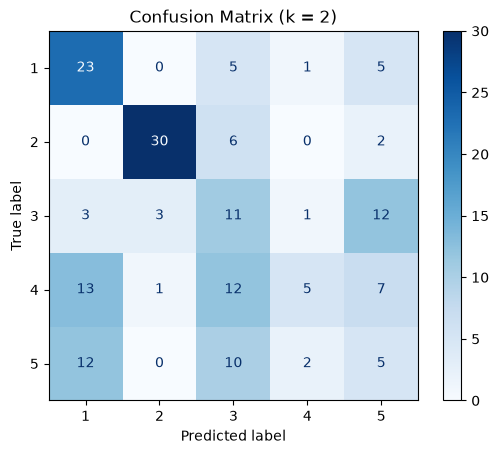

total accuracy: 43.8%


In [211]:
optimal_model = KNeighborsClassifier(n_neighbors=k_star) # Build the model
optimal_model.fit(X_train, y_train) # Fit the optimal model using k = 11
optimal_model_valid_hat = optimal_model.predict(X_valid) # Predict on the validation set

confusion_matrix = metrics.confusion_matrix(y_valid, optimal_model_valid_hat) # Build the confusion matrix
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix,
                                            display_labels = [1,2,3,4,5]) # Build the display, showing all 5 mine types
cm_display.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (k = 11)")
plt.show()

accuracy = metrics.accuracy_score(y_valid, optimal_model_valid_hat)
print(f"total accuracy: {accuracy:.1%}")


The total model is only 43.8% accurate on this validation dataset, and some `mine_type` are much more accurate than others. For example, type 2 is the most accurate with 26 out of 31 correct predictions, and type 1 falls closely behind with 24 out of 32 correct predictions. However, the least accurate type by far is type 5. There was only 1 correct prediction in all 31 instances of type 5 in this  dataset. Mine type 4 falls closely behind with 6 correct predicitons out of 37.

**5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.**

In practice, you must be vary careful when using voltage, mine height, and soil type to predict the type of mine, especially if the predicted label is mine type 4 or 5. Although the actual accuracies per mine type and in total would depend on the k chosen and the split of training to testing data, based on my work here, you can be more confident in the prediction of a mine type 2. I would not blindly use these predictions in the field, especially due to the high stakes of determing what type of mine you are working with.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** cccd7e8f56b93afe82f1c26cd272c51f51f06e68
- **AI tool and model used:** Claude Opus 5.5

### *Prompts used

1. I have attached the rubric, my phase 1 work, and our lecture notes for the week for my 3nd DS 3001 lab. Can you please carefully review, audit, and propose revisions if necessary for this lab? I want you to provide me with a concise list of the changes necessary to score 100% on the rubric.
2. Can you please make sure you give me edits that actually impact grading and would improve my work? You don't need to come up with extra changes just to get a certain number.

### *AI-proposed changes


1. Q2.4 analysis uses old numbers. Your text describes a different matrix: 26/31, 24/32, 1/31 and 6/37. None of those match the current k = 11 matrix, so a grader comparing your writing to your output will see the mismatch. The correct numbers:
- Type 2: 30/38 correct (79%)
- Type 1: 23/34 (68%)
- Type 3: 11/30 (37%)
- Type 5: 5/29 (17%)
- Type 4: 5/38 (13%), the worst
- Also cover "where it's less accurate" by naming the main confusions. Type 4 is mostly predicted as 1 (13 times) or 3 (12 times). Type 5 is mostly predicted as 1 (12) or 3 (10). Type 3 is often predicted as 5 (12).
2. Q2.5 needs an "accurate but still lots of mistakes" point. The question is getting at reading the confusion matrix down each column, not just across rows. Type 1 is a good example:
- It catches 23 of 34 real type 1s.
- But only 23 of its 51 type 1 predictions are correct (45%), because 28 actual type 3, 4 and 5 mines get labeled type 1.
- Type 2 predictions are right 30 of 34 times (88%), so type 2 is the only prediction you can trust.
Then give concrete advice: trust type 2 predictions, treat every other prediction as uncertain, and never act on a type 1 prediction without confirming it.
3. Q1.3: The formula is missing the observed value. Change it to "the sum of squared differences between the observed values and the predictions."
4. Q1.6: Rewrite or delete "You could have a much more accurate model if you ignored the values that the model was least confident in." As written, it isn't correct. Replace it with what the weakness actually is: a label hides the difference between a close vote and a unanimous one, so you can't flag uncertain cases.
5. Q1.2: SSE is a regression metric, so it isn't the right comparison here. Say "overall accuracy doesn't show which classes are misclassified" instead.
6. Q2.3 text: Change "fit the validation (and training) models" to "fit each model on the training set and predicted on both the training and validation sets." Models are never fit on validation data.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | I re-ran my code in full before commiting it to git, and I forgot to edit the numbers that confusion matrix produced. I definitely need to update these to the correct numbers. I have verified by counting the totals in each row and column in the confusion matrix.|
| 2 | Accept | Adding this detail only enhances my answer, so I accept it. I tested it by manually counting the percentages through the data shown on the confusion matrix.|
| 3 | Accept | I accept this change because it adds more detail to my SSE answer. It is measuring the distance between predicted values and observed values, and I didn't make that explicitly clear in my answer.|
| 4 | Accept | My original statement was strong, so I used Claude's version instead. I validated this by thinking through my understanding of what a class label as a prediction actual outputs, and I agreed with Claude's work.|
| 5 | Accept | That was a good catch. Like I explained in my process when I was selecting k, you don't use SSE for classification. I was trying to provide a general example for how overall accuracy doesn't give the full picture.|
| 6 | Accept | I didn't fit the model on the validation set because that wouldn't make much sense. I accepted this change because it more accurately described my process of iterating through different ks.|

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

### Q1 ###

**1. What is the difference between regression and classification?**
- Regression and classification are two different types of machine learning models. Regression predicts a numeric outcome, and is therefore used when we want to predict numerical results. Classification predicts a categorical target, and is therefore used when we want to predict cateogrical results. You use `KNeighborsRegressor` for regression and `KNeighborsClassifier` for classification when using scikit-learn models. Additionally, when using regression, you average the neighbors when combining observed outcomes to determine the prediction result, whereas you take the majority for classification.

**2. What is a confusion table? What does it help us understand about a model's performance?**
- A confusion table counts predictions by actual class and predicted class. Column headers show whether the model predicts negative or positive results, and row headers show the actual classes. The result of the matrix (for a binary variable) is 4 scenarios: true negative, false positive, false negative, and true positive. It helps us understand which values are missclassified as false positives or false negatives when making a categorical prediction. This is helpful because overall accuracy doesn't show which particular classes are missclassified. 

**3. What does the SSE quantify about a particular model?**
- The SSE is a single number that can be viewed as a ruler for model performance. For a particular k value, it quanitfies the error between the predictions and observations. It is calculated by suming the square of the difference between predictions and observed values for each sample of data in a fitted model.

**4. What are overfitting and underfitting?**
- Because predictions change when the set of nearest neighbors change, choosing the correct k is very important. Overfitting is when you choose a k that is too small, so the model captures too much noise in the data. This means that the predictions will vary a lot when you slighly change any input features. Underfitting is when you choose a k that is too large, so it captures too little of the datapoint and doesn't provide helpful insights. This means that no matter how much you vary the input, the predictions would be nearly the same.

**5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?**
- Splitting the data into training and testing sets allows you to test how well the model predicts new observations (the testing set), rather than just predicting the outcome variable that it has been trained on. Once you fit models on a training set, you then compare how they perform on the testing set. Choosing $k$ is particularly important because a main purpose of the model is to be able to generalize it, or make robust predictions on unseen data. Different $k$ values control this generalization ability of a model, like I discussed in the overfitting and underfitting question above. By iterating over different $k$ options, you can test the model on your testing set to determine the particular $k$ that has the lowest SSE or the highest accuracy. 

**6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.**
- The strengths of reporting a class label as a prediction are that it is simpler and easier to interpret, since the model predicts one output value for each combination of feature variables. This can be beneficial if there are many different classes that the output variable could land in, and it also allows you to build a confusion matrix. The main weakness of this approach is that it ignores how confident the model is in it's prediction. One singular label hides the difference between a close vote and a unanimous one, so you can't flag cases where the model was uncertain. 
- The strengths of reporting a probability distribution over class labels are that the model provides more information for you to interpret and you have information into how confident the model is with each prediction. However, the main weakness of this approach is that it can make interpretation much more challenging with an overload of data.

### Q2 ###

**1. Load the data. Perform some EDA, summarizing the target label and the features.**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

df = pd.read_csv("./data/land_mines.csv")
print(df.shape) 
df.head()

(338, 4)


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


The data has 4 variables and 338 observations. The target label is `mine_type`, and the feature variables are `voltage`, `height`, and `soil`. I will now explore the target label.

In [ ]:
print('number of null values:', df['mine_type'].isnull().sum()) # Count null values
print(df['mine_type'].value_counts()) 
print(df['mine_type'].describe())

number of null values: 0
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
count    338.000000
mean       2.952663
std        1.419703
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: mine_type, dtype: float64


The target label of `mine_type` is an categorical variable that is an integer type. There are no null values, and it has 5 possible values: 1, 2, 3, 4, and 5. The most common mine type is 1 with 71 occurances, and the least common is 5 with 65 occurances. As `mine_type` increases, the number of occurances slightly decreases, although not to a meaningful degree.

number of null values: 0
count    338.000000
mean       0.430634
std        0.195819
min        0.197734
25%        0.309737
50%        0.359516
75%        0.482628
max        0.999999
Name: voltage, dtype: float64
voltage
0.999999    18
0.335347     7
0.314199     7
0.302114     7
0.296072     6
            ..
0.446284     1
0.391178     1
0.378157     1
0.319939     1
0.519637     1
Name: count, Length: 196, dtype: int64


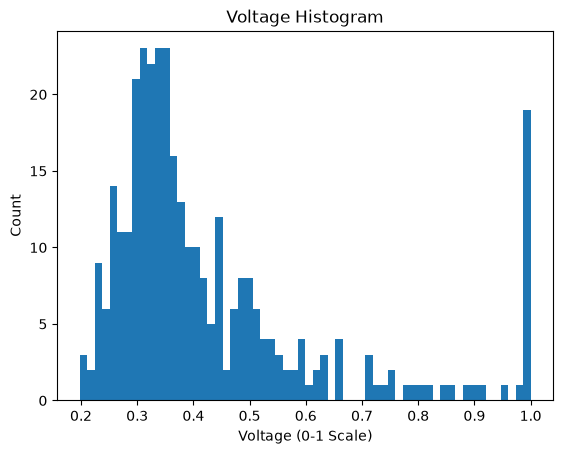

In [ ]:
print('number of null values:', df['voltage'].isnull().sum()) # Count null values
print(df['voltage'].describe())
print(df['voltage'].value_counts())
voltage_hist = df['voltage'].hist(bins=60, grid=False) # Create histogram
voltage_hist.set_title('Voltage Histogram')
voltage_hist.set_xlabel('Voltage (0-1 Scale)')
voltage_hist.set_ylabel('Count')
plt.show()


`voltage` is a numeric feature variable that is already on a 0-1 scale, so no additional feature scaling is needed. It is a float object type with no null values. Values range from approximately 0.20 to 0.99, with a mean value of 0.43. The distribution is skewed right, as it has a long tail of higher values, and it has a spike at 0.99 with 18 observations at that value. 

number of null values: 0
count    338.000000
mean       0.508876
std        0.306043
min        0.000000
25%        0.272727
50%        0.545455
75%        0.727273
max        1.000000
Name: height, dtype: float64
height
0.181818    30
0.545455    30
0.636364    30
0.454545    29
0.727273    29
0.818182    29
0.363636    29
0.272727    28
0.909091    28
1.000000    27
0.090909    27
0.000000    22
Name: count, dtype: int64


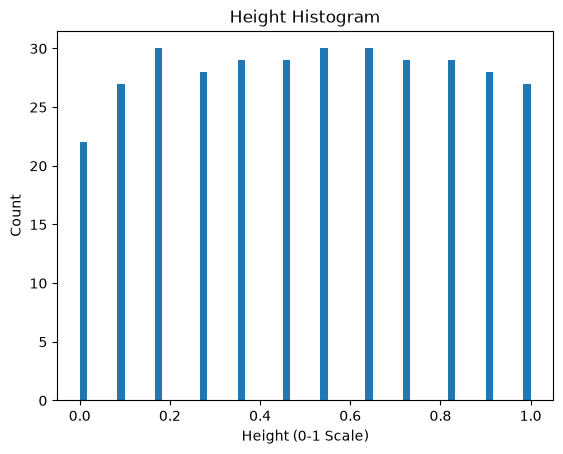

In [ ]:
print('number of null values:', df['height'].isnull().sum()) # Count null values
print(df['height'].describe())
print(df['height'].value_counts())
height_hist = df['height'].hist(bins=60, grid=False) # Create histogram
height_hist.set_title('Height Histogram')
height_hist.set_xlabel('Height (0-1 Scale)')
height_hist.set_ylabel('Count')
plt.show()

`height` is also a numeric feature variable that has been scaled to fall between 0 and 1. It is a float object type with no null values. Height only has 12 distinct values, ranging from 0.0 to 1.0. I will keep 0.0, because that doesn't represent a height of 0 since the variable has been scaled. It instead represents the smallest height in the dataset. The mean height is 0.5, and the distribution is relatively uniform throughout each height. 

number of null values: 0
count    338.000000
mean       0.503550
std        0.344244
min        0.000000
25%        0.200000
50%        0.600000
75%        0.800000
max        1.000000
Name: soil, dtype: float64
soil
0.0    59
0.8    58
0.6    57
1.0    57
0.4    56
0.2    51
Name: count, dtype: int64


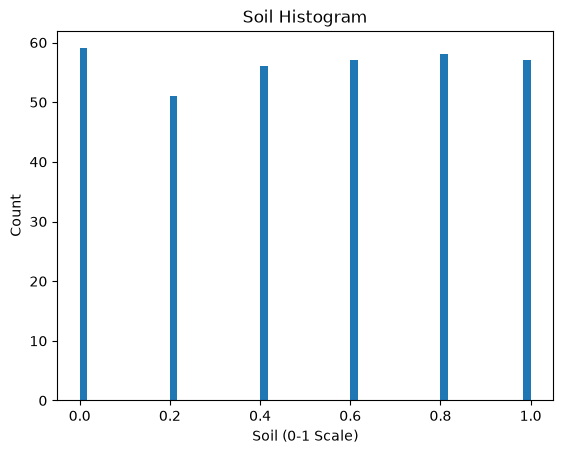

In [ ]:
print('number of null values:', df['soil'].isnull().sum()) # Count null values
print(df['soil'].describe())
print(df['soil'].value_counts())
soil_hist = df['soil'].hist(bins=60, grid=False) # Create histogram
soil_hist.set_title('Soil Histogram')
soil_hist.set_xlabel('Soil (0-1 Scale)')
soil_hist.set_ylabel('Count')
plt.show()

Finally, `soil` is another feature variable that is already scaled to land between 0 and 1. There are only 6 distinct values (0.0, 0.2, 0.4, 0.6, 0.8, and 1.0). The distribution is relatively even among values, with 59 counts of 0.0 on the high end and 51 counts of 0.2 on the low end. There are no null values. Because each value is evenly spaced, and "soil" is not a measurable variable, it appears to be categorical where each value represents a different type of soil. However, I can't be positive.

Since the values of all the feature variables are already on a 0-1 scale, there is no need to do additional scaling before building the model.

**2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)**


In [ ]:
X = df[['voltage','height','soil']] # Raw feature variables
y = df['mine_type'] # Target variable

X_train, X_valid, y_train, y_valid = train_test_split(X, y,
    test_size=0.5, random_state=65) # Split the data 50/50 into training and test/validation sets.

print(X_train.describe())

          voltage      height        soil
count  169.000000  169.000000  169.000000
mean     0.416000    0.532006    0.479290
std      0.183133    0.308232    0.354037
min      0.197734    0.000000    0.000000
25%      0.306495    0.272727    0.200000
50%      0.356495    0.545455    0.400000
75%      0.467341    0.818182    0.800000
max      0.999999    1.000000    1.000000


After spliting the data 50/50, I can see that my feature training data set has 169 rows, exactly half of the 338 rows in the initial dataset. 

**3. Build a $k$-NN classifier. Explain how you select $k$.**


In [ ]:
k = round(len(X_train) ** 0.5) # Starting my model with a k that is based off the square root of n
print(k)

13


I started off by selecting k based on the square root of the number of rows in my training dataset. Because it was 13, I then chose to test the accuracy on different k's from 1-50, which covers a wide range around the square root of n. I use accuracy versus SSE to determine which k is best because the target is a categorical variable, and with categorical variables, the prediction is either correct or incorrect.  

In [ ]:
ks = np.arange(1, 51) # Test ks from 1-50
valid_accuracy = [] # Empty lists to accumulate accuracies for different validation set ks  
train_accuracy = [] # Empty lists to accumulate accuracies for different training set ks  

for k in ks: # Loop through all the test ks
   candidate = KNeighborsClassifier(n_neighbors=int(k)) 
   candidate.fit(X_train, y_train)
   valid_hat = candidate.predict(X_valid)
   train_hat = candidate.predict(X_train)
   valid_accuracy.append(np.sum( # Sum the correct predictions / total predictions to determine the accuracy of the validation set
      (y_valid.to_numpy() == valid_hat) / len(y_valid)
   ))
   train_accuracy.append(np.sum( # Sum the correct predictions / total predicitons to determine the accuracy of the training set
      (y_train.to_numpy() == train_hat) / len(y_train)
   ))
k_star = int(ks[np.argmax(valid_accuracy)]) # Determine the k with the highest accuracy
print(f"k: {k_star}. Validation accuracy: {max(valid_accuracy):.1%}.")

k: 11. Validation accuracy: 43.8%.


For this split, the validation accuracy is highest at 43.8% when k = 11. I determined this by iterating through ks 1-50. For each k, I built a new classification model, fit each model on the training set, predicted the model on both the training and validation sets, and then determined their accuracy by dividing the number of correct predictions by total predictions.

**4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?**

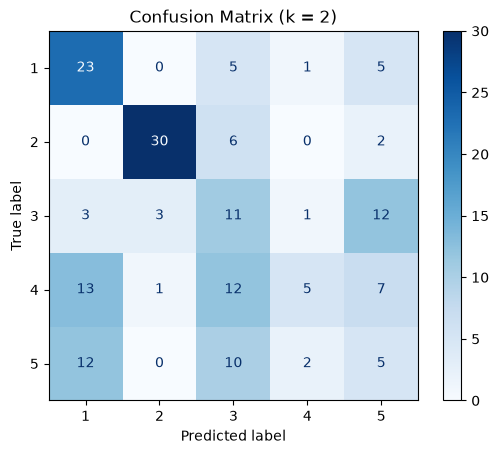

total accuracy: 43.8%


In [ ]:
optimal_model = KNeighborsClassifier(n_neighbors=k_star) # Build the model
optimal_model.fit(X_train, y_train) # Fit the optimal model using k = 11
optimal_model_valid_hat = optimal_model.predict(X_valid) # Predict on the validation set

confusion_matrix = metrics.confusion_matrix(y_valid, optimal_model_valid_hat) # Build the confusion matrix
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix,
                                            display_labels = [1,2,3,4,5]) # Build the display, showing all 5 mine types
cm_display.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (k = 11)")
plt.show()

accuracy = metrics.accuracy_score(y_valid, optimal_model_valid_hat)
print(f"total accuracy: {accuracy:.1%}")


The total model is only 43.8% accurate on this validation dataset, and some `mine_type` are much more accurate than others. For example, type 2 is the most accurate with 30 out of 38 (79%) correct predictions, and type 1 falls closely behind with 22 out of 34 (68%) correct predictions. However, the least accurate types are type 4 and 5, at 13% and 17% correct, respectively. Type 3 correctly predicted 11 out of 30 instances (37%). Additionally, type 4 is most often incorrectly predicted as 1 (13 times) or 3 (12 times). Type 5 is most often incorrectly predicted as 1 (12 times) or 3 (10 times).

**5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.**

In practice, you must be vary careful when using voltage, mine height, and soil type to predict the type of mine, especially for mine types 4 or 5, which the model rarely identifies correctly. Although the actual accuracies per mine type and in total would depend on the k chosen and the split of training to testing data, based on my work here, you can be more confident in the prediction of a mine type 2. I would not blindly use these predictions in the field, especially due to the high stakes of determing what type of mine you are working with.

Another aspect that is important to consider is that some mine types are accurate, but they still make plently of mistakes. For example, mine type 1 is accurately caught 68% of the time, but it is predicted for other mine types frequently, meaning that only 23 of its 51 type 1 predictions are correct (45%). On the other hand, type 2 is not a common false prediction, so you can be more confident in the field that type 2 predictions are accurate.

### *Reflection on AI assistance
In your own words without generative AI.

Similar to my previous labs, the main improvements were catching numeric and wording inconsistencies. This time, AI was super helpful in picking up on the fact that I re-ran my file from start to finish. As a result, accuracies in the confusion matrix were different than what my descriptions referred to. Before I committed Phase I to Github, I added a seed variable when I split my training and testing variable to prevent this issue from continuing to happen, but I forgot to update that specific description for the final time. I updated the new k value and overall accuracy metric that my seeded train/test split created. I didn’t find any AI mistakes in this review process. I only edited the specific areas that Claude suggested I change since there were only a few of them, so I only had to verify those 6 points. I did so by recalculating and looking over the actual numbers in the confusion matrix and making sure I had a solid understanding of the wording changes that AI advised I make. I don’t have any remaining concerns after the AI assistance process. This lab helped me gain a much better understanding of knn models! 